# Debug: LoG Blob Detection 驗證

用 `cell_24.png` 測試 **Laplacian of Gaussian (LoG)** blob detection，取代傳統 RGB/HSV 閾值偵測紅黑 dot。

LoG 的核心概念：在不同 scale (sigma) 下做 Laplacian 運算，找出「局部極值」的圓形結構，不依賴絕對顏色閾值。

Shape: (74, 83, 3), dtype: uint8


/home/sec312/project/tsgh/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sec312/project/tsgh/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sec312/project/tsgh/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24433 (\N{CJK UNIFIED IDEOGRAPH-5F71}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sec312/project/tsgh/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


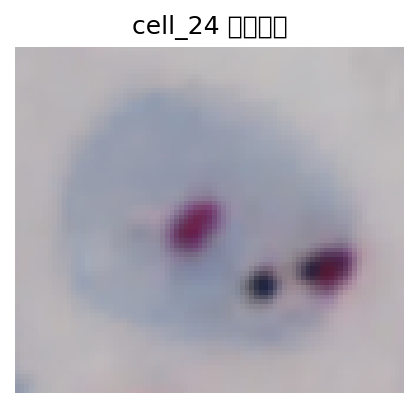

In [11]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from scipy import ndimage
from skimage.feature import blob_log, blob_dog, blob_doh
from skimage import color, exposure

%matplotlib inline
plt.rcParams['figure.dpi'] = 150

# 載入 cell_24
img_path = "output/tile_x55296_y94208/cells/cell_24.png"
img = np.array(Image.open(img_path))
print(f"Shape: {img.shape}, dtype: {img.dtype}")

plt.figure(figsize=(4, 3))
plt.imshow(img)
plt.title("cell_24 原始影像")
plt.axis("off")
plt.show()

## Step 1: 準備 LoG 輸入通道

LoG 偵測的是「局部暗 blob」（亮度的局部最小值）。所以：
- **黑 dot**：直接用 brightness（暗度地圖），LoG 找暗區 blob
- **紅 dot**：用 redness map（R 相對於 G、B 的突出程度），LoG 找「紅色突出」的 blob

/tmp/ipykernel_3918300/4120438228.py:43: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3918300/4120438228.py:43: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3918300/4120438228.py:43: UserWarning: Glyph 24433 (\N{CJK UNIFIED IDEOGRAPH-5F71}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3918300/4120438228.py:43: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3918300/4120438228.py:43: UserWarning: Glyph 40657 (\N{CJK UNIFIED IDEOGRAPH-9ED1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3918300/4120438228.py:43: UserWarning: Glyph 36664 (\N{CJK UNIFIED IDEOGRAPH-8F38}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3918300/4120438228.py:43: UserWarning: Glyph 20837 (\N{CJK UN

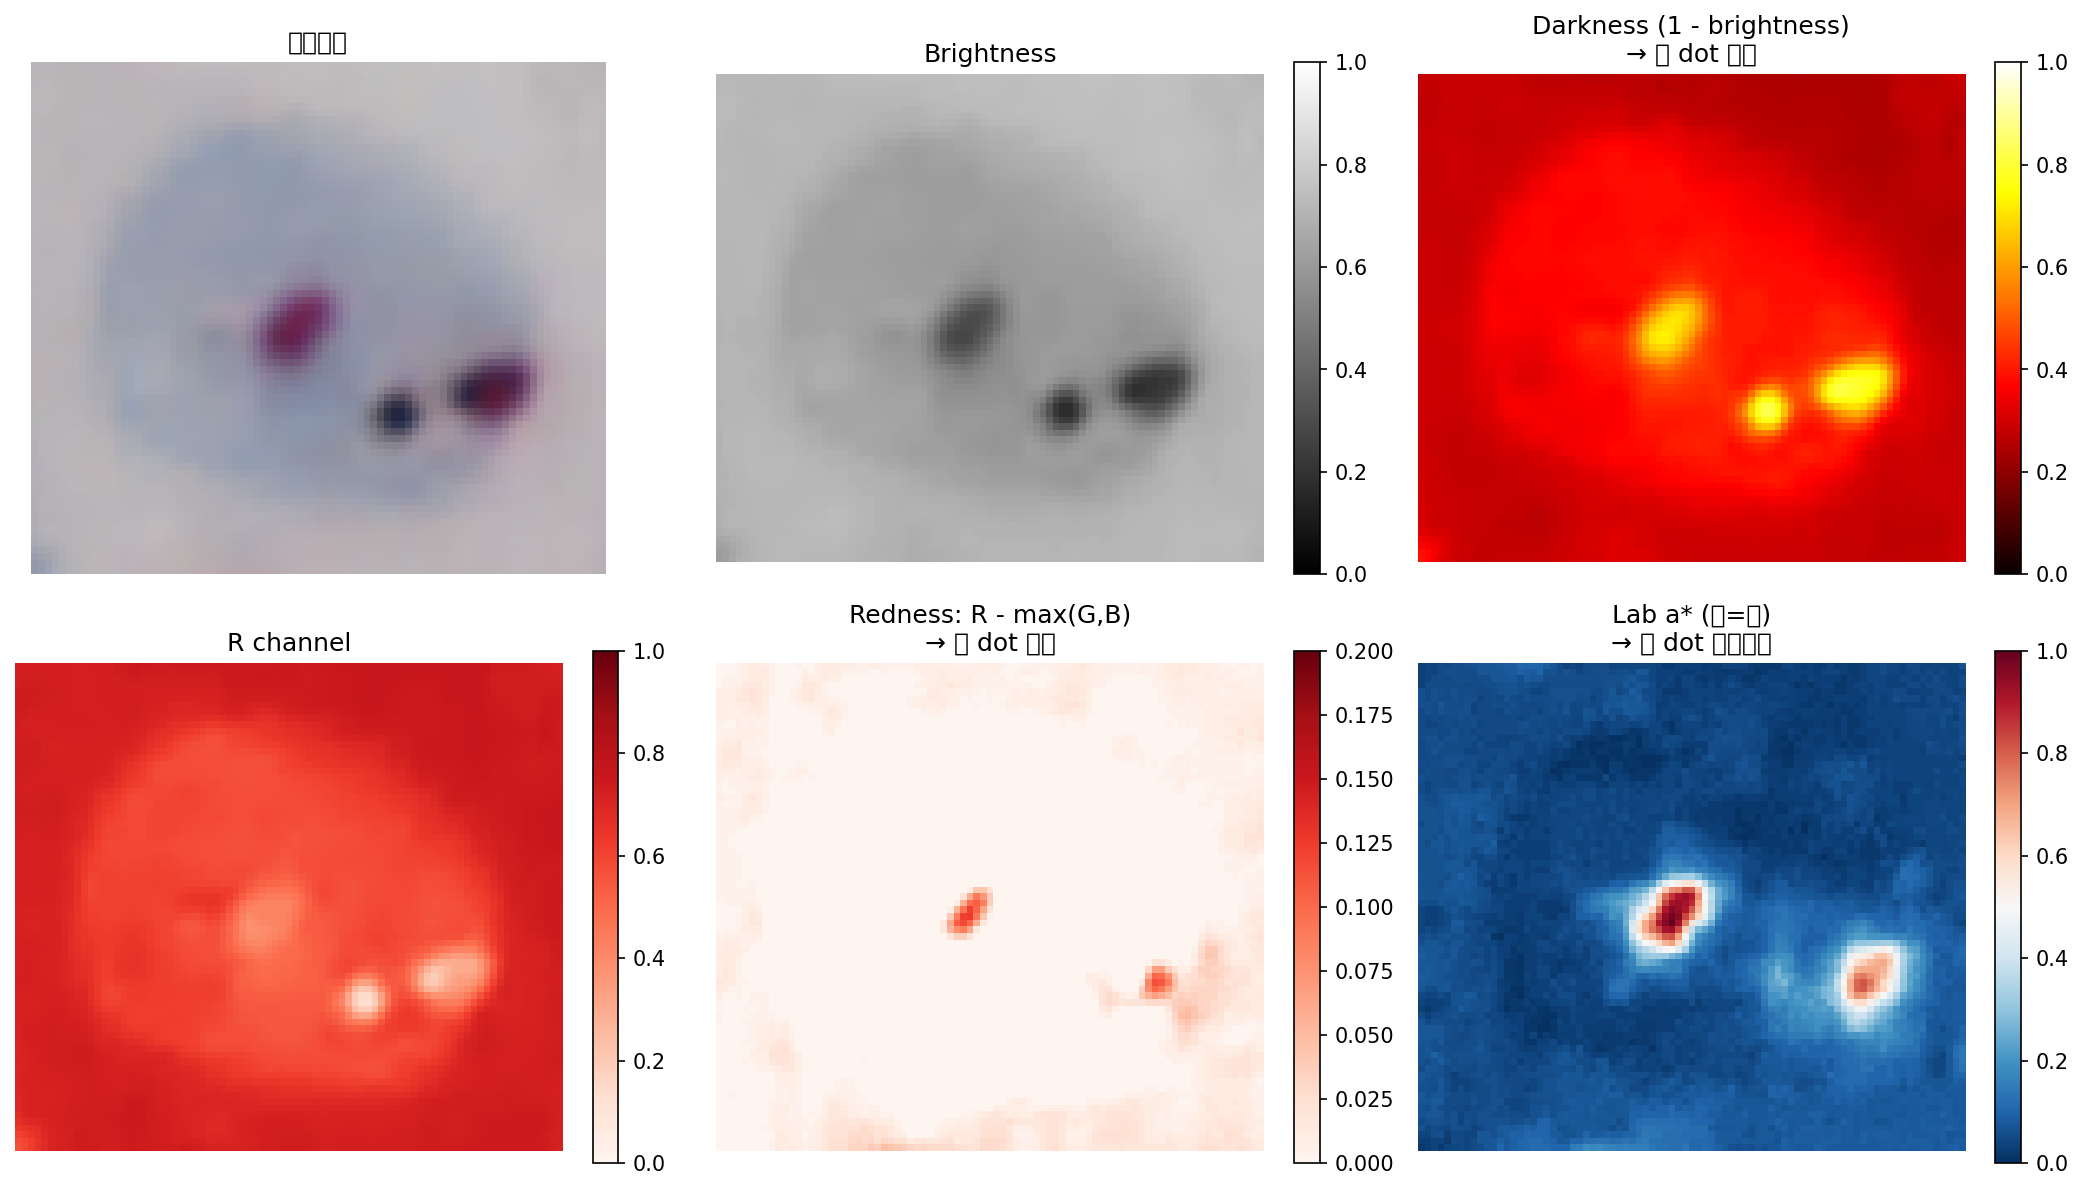

Darkness: min=0.243, max=0.824
Redness:  min=0.000, max=0.125
Lab a*:   min=-0.5, max=37.7


In [12]:
img_f = img.astype(np.float64) / 255.0
r, g, b = img_f[:,:,0], img_f[:,:,1], img_f[:,:,2]

# --- 黑 dot 用: darkness map (反轉亮度，讓暗的地方變「亮」方便 LoG 找 bright blob) ---
brightness = img_f.mean(axis=2)
darkness = 1.0 - brightness  # 越暗 → 越高

# --- 紅 dot 用: redness map ---
# 方法: R 通道相對突出程度 = R - max(G, B)
# 紅色 dot 的位置，這個值會明顯 > 0
redness = r - np.maximum(g, b)
redness = np.clip(redness, 0, 1)  # 只保留 R 突出的部分

# --- 另一個紅 dot 候選: 色彩解卷積後的 red stain channel ---
# 用 Lab 色彩空間的 a* 通道 (正值 = 紅/品紅)
lab = color.rgb2lab(img_f)
a_star = lab[:,:,1]  # 正值 = 紅, 負值 = 綠
a_star_norm = np.clip(a_star / a_star.max(), 0, 1) if a_star.max() > 0 else a_star

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes[0, 0].imshow(img)
axes[0, 0].set_title("原始影像")
im1 = axes[0, 1].imshow(brightness, cmap="gray", vmin=0, vmax=1)
axes[0, 1].set_title("Brightness")
plt.colorbar(im1, ax=axes[0, 1], fraction=0.046)
im2 = axes[0, 2].imshow(darkness, cmap="hot", vmin=0, vmax=1)
axes[0, 2].set_title("Darkness (1 - brightness)\n→ 黑 dot 輸入")
plt.colorbar(im2, ax=axes[0, 2], fraction=0.046)

im3 = axes[1, 0].imshow(r, cmap="Reds", vmin=0, vmax=1)
axes[1, 0].set_title("R channel")
plt.colorbar(im3, ax=axes[1, 0], fraction=0.046)
im4 = axes[1, 1].imshow(redness, cmap="Reds", vmin=0, vmax=0.2)
axes[1, 1].set_title("Redness: R - max(G,B)\n→ 紅 dot 輸入")
plt.colorbar(im4, ax=axes[1, 1], fraction=0.046)
im5 = axes[1, 2].imshow(a_star_norm, cmap="RdBu_r", vmin=0, vmax=1)
axes[1, 2].set_title("Lab a* (正=紅)\n→ 紅 dot 備選輸入")
plt.colorbar(im5, ax=axes[1, 2], fraction=0.046)

for ax in axes.flat:
    ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Darkness: min={darkness.min():.3f}, max={darkness.max():.3f}")
print(f"Redness:  min={redness.min():.3f}, max={redness.max():.3f}")
print(f"Lab a*:   min={a_star.min():.1f}, max={a_star.max():.1f}")

## Step 2: LoG Blob Detection — 黑色 Dot

`blob_log(image, min_sigma, max_sigma, threshold)`:
- `min_sigma` / `max_sigma`: blob 的最小/最大半徑（pixels）
- `threshold`: 相對強度閾值（越低越敏感）
- 回傳 `(y, x, sigma)` 陣列，每個 blob 的中心座標 + 估計半徑 ≈ `sigma * √2`

偵測到 4 個黑色 blob candidates


/tmp/ipykernel_3918300/1544896800.py:37: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3918300/1544896800.py:37: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3918300/1544896800.py:37: UserWarning: Glyph 24433 (\N{CJK UNIFIED IDEOGRAPH-5F71}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3918300/1544896800.py:37: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3918300/1544896800.py:37: UserWarning: Glyph 40657 (\N{CJK UNIFIED IDEOGRAPH-9ED1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


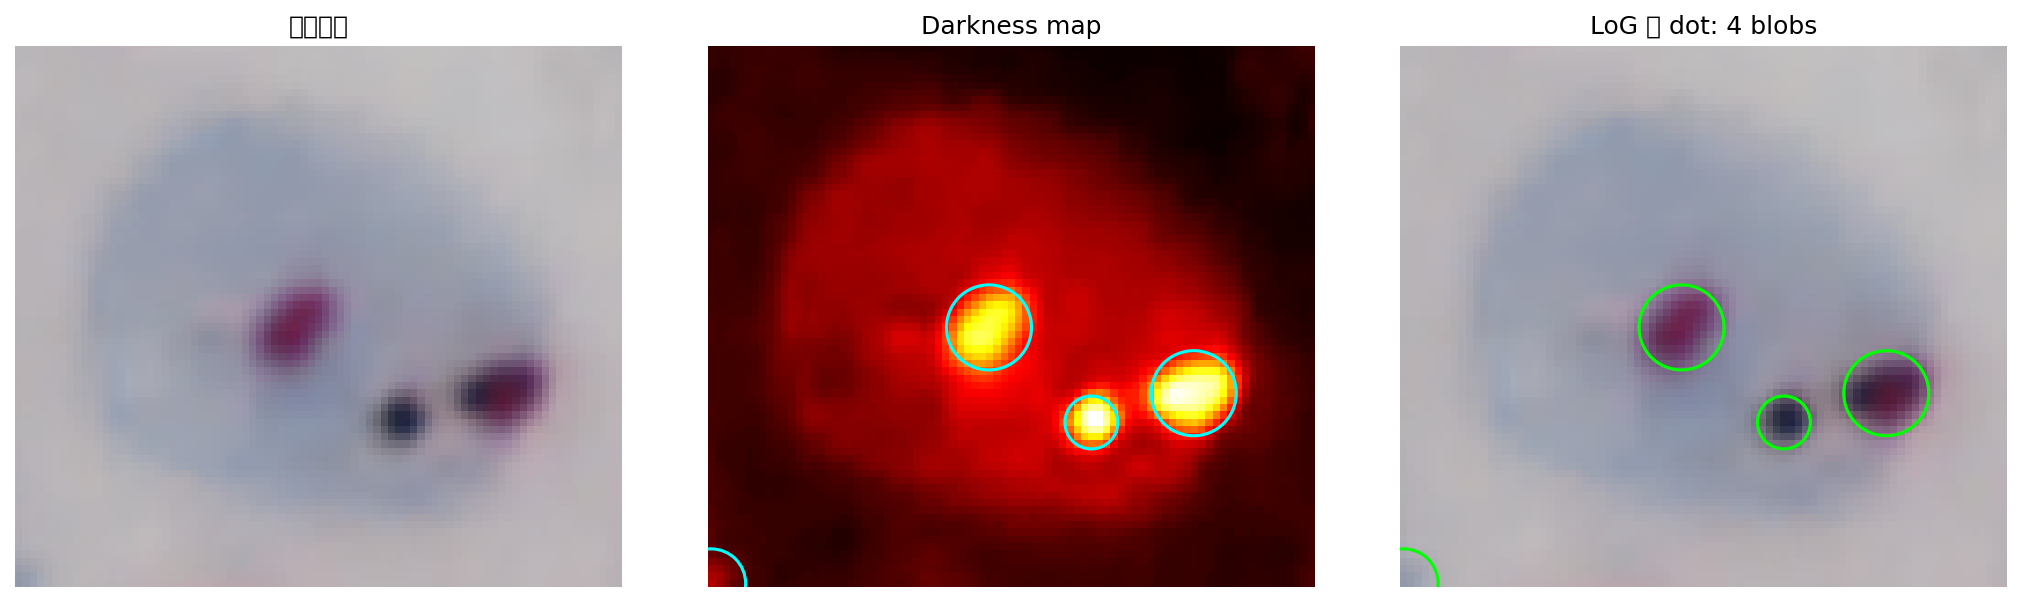

  Blob 0: pos=(47,66), sigma=4.1, radius=5.8px, darkness=0.793, raw_RGB=[79,26,53]
  Blob 1: pos=(51,52), sigma=2.6, radius=3.6px, darkness=0.822, raw_RGB=[34,39,63]
  Blob 2: pos=(38,38), sigma=4.1, radius=5.8px, darkness=0.714, raw_RGB=[108,35,76]
  Blob 3: pos=(73,0), sigma=3.3, radius=4.7px, darkness=0.388, raw_RGB=[145,153,170]


In [13]:
# LoG on darkness map → 黑 dot
# DISH 的 black dot (silver enhanced HER2) 通常直徑約 3-10 pixels

blobs_black = blob_log(
    darkness,
    min_sigma=1,
    max_sigma=8,
    num_sigma=10,
    threshold=0.05,
)

print(f"偵測到 {len(blobs_black)} 個黑色 blob candidates")

# 畫出結果
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(img)
axes[0].set_title("原始影像")

axes[1].imshow(darkness, cmap="hot")
axes[1].set_title("Darkness map")

axes[2].imshow(img)
axes[2].set_title(f"LoG 黑 dot: {len(blobs_black)} blobs")

for blob in blobs_black:
    y, x, sigma = blob
    radius = sigma * np.sqrt(2)
    circle = plt.Circle((x, y), radius, color="lime", linewidth=1.5, fill=False)
    axes[2].add_patch(circle)
    # 也在 darkness map 上畫
    circle2 = plt.Circle((x, y), radius, color="cyan", linewidth=1.5, fill=False)
    axes[1].add_patch(circle2)

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

# 印出每個 blob 的資訊
for i, blob in enumerate(blobs_black):
    y, x, sigma = blob
    radius = sigma * np.sqrt(2)
    yi, xi = int(round(y)), int(round(x))
    raw_rgb = img[yi, xi] if 0 <= yi < img.shape[0] and 0 <= xi < img.shape[1] else [0,0,0]
    print(f"  Blob {i}: pos=({yi},{xi}), sigma={sigma:.1f}, radius={radius:.1f}px, "
          f"darkness={darkness[yi,xi]:.3f}, raw_RGB=[{raw_rgb[0]},{raw_rgb[1]},{raw_rgb[2]}]")

## Step 3: LoG Blob Detection — 紅色 Dot

分別用 redness map 和 Lab a* 通道來試

Redness map → 2 blobs
Lab a* map  → 3 blobs


/tmp/ipykernel_3918300/609660472.py:54: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3918300/609660472.py:54: UserWarning: Glyph 22294 (\N{CJK UNIFIED IDEOGRAPH-5716}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3918300/609660472.py:54: UserWarning: Glyph 40643 (\N{CJK UNIFIED IDEOGRAPH-9EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3918300/609660472.py:54: UserWarning: Glyph 38738 (\N{CJK UNIFIED IDEOGRAPH-9752}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/sec312/project/tsgh/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22294 (\N{CJK UNIFIED IDEOGRAPH-5716}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sec312/project/tsgh/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 40643 (\N{CJK UNIFIED IDEOGRAPH-9EC3}) missing fr

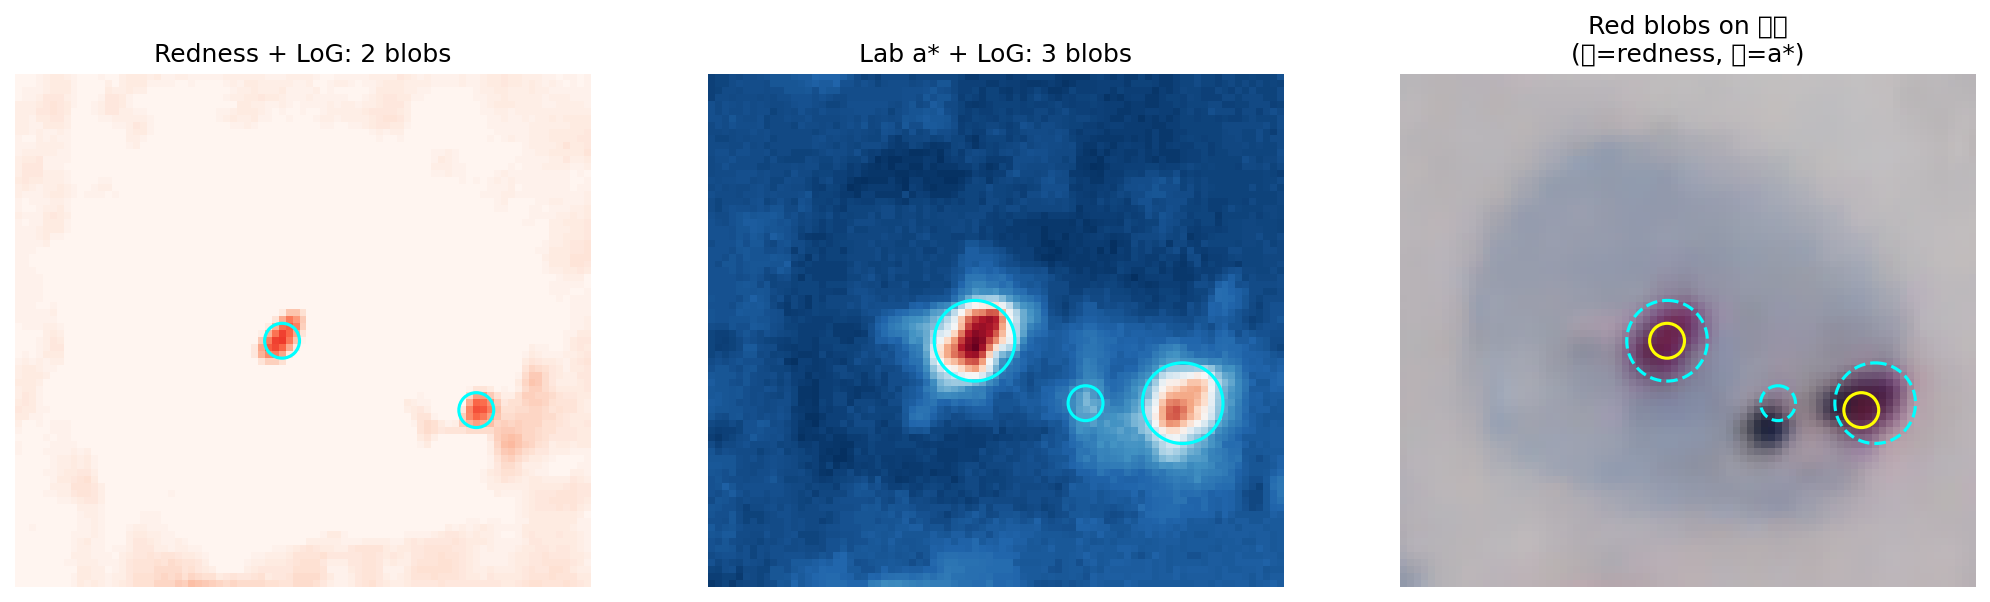


=== Redness blobs ===
  Blob 0: pos=(38,38), sigma=1.8, redness=0.125, raw_RGB=[108,35,76]
  Blob 1: pos=(48,66), sigma=1.8, redness=0.114, raw_RGB=[83,26,54]

=== Lab a* blobs ===
  Blob 0: pos=(38,38), sigma=4.1, a*=36.8, raw_RGB=[108,35,76]
  Blob 1: pos=(47,68), sigma=4.1, a*=27.5, raw_RGB=[82,32,63]
  Blob 2: pos=(47,54), sigma=1.8, a*=10.4, raw_RGB=[121,104,123]


In [14]:
# --- 方法 A: LoG on redness map ---
blobs_red_redness = blob_log(
    redness,
    min_sigma=1,
    max_sigma=8,
    num_sigma=10,
    threshold=0.02,  # redness 值較小，閾值要低一點
)

# --- 方法 B: LoG on Lab a* channel ---
blobs_red_astar = blob_log(
    a_star_norm,
    min_sigma=1,
    max_sigma=8,
    num_sigma=10,
    threshold=0.05,
)

print(f"Redness map → {len(blobs_red_redness)} blobs")
print(f"Lab a* map  → {len(blobs_red_astar)} blobs")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Redness 結果
axes[0].imshow(redness, cmap="Reds", vmin=0, vmax=0.2)
axes[0].set_title(f"Redness + LoG: {len(blobs_red_redness)} blobs")
for blob in blobs_red_redness:
    y, x, sigma = blob
    circle = plt.Circle((x, y), sigma * np.sqrt(2), color="cyan", linewidth=1.5, fill=False)
    axes[0].add_patch(circle)

# Lab a* 結果
axes[1].imshow(a_star_norm, cmap="RdBu_r")
axes[1].set_title(f"Lab a* + LoG: {len(blobs_red_astar)} blobs")
for blob in blobs_red_astar:
    y, x, sigma = blob
    circle = plt.Circle((x, y), sigma * np.sqrt(2), color="cyan", linewidth=1.5, fill=False)
    axes[1].add_patch(circle)

# 合併在原圖上
axes[2].imshow(img)
axes[2].set_title("Red blobs on 原圖\n(黃=redness, 青=a*)")
for blob in blobs_red_redness:
    y, x, sigma = blob
    circle = plt.Circle((x, y), sigma * np.sqrt(2), color="yellow", linewidth=1.5, fill=False)
    axes[2].add_patch(circle)
for blob in blobs_red_astar:
    y, x, sigma = blob
    circle = plt.Circle((x, y), sigma * np.sqrt(2), color="cyan", linewidth=1.5, fill=False, linestyle="--")
    axes[2].add_patch(circle)

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

# 印出 redness blobs 資訊
print("\n=== Redness blobs ===")
for i, blob in enumerate(blobs_red_redness):
    y, x, sigma = blob
    yi, xi = int(round(y)), int(round(x))
    raw_rgb = img[yi, xi] if 0 <= yi < img.shape[0] and 0 <= xi < img.shape[1] else [0,0,0]
    print(f"  Blob {i}: pos=({yi},{xi}), sigma={sigma:.1f}, "
          f"redness={redness[yi,xi]:.3f}, raw_RGB=[{raw_rgb[0]},{raw_rgb[1]},{raw_rgb[2]}]")

print("\n=== Lab a* blobs ===")
for i, blob in enumerate(blobs_red_astar):
    y, x, sigma = blob
    yi, xi = int(round(y)), int(round(x))
    raw_rgb = img[yi, xi] if 0 <= yi < img.shape[0] and 0 <= xi < img.shape[1] else [0,0,0]
    print(f"  Blob {i}: pos=({yi},{xi}), sigma={sigma:.1f}, "
          f"a*={a_star[yi,xi]:.1f}, raw_RGB=[{raw_rgb[0]},{raw_rgb[1]},{raw_rgb[2]}]")

## Step 4: 區分紅 vs 黑 — 用顏色分類 blob

LoG 只告訴我們「這裡有一個圓形物件」，不分顏色。
所以要對每個偵測到的 blob 中心做顏色判斷：是紅色 dot 還是黑色 dot。

In [15]:
# 合併所有 blob 來源 (去重)
all_blobs = []
sources = []

for blob in blobs_black:
    all_blobs.append(blob)
    sources.append("darkness")
for blob in blobs_red_redness:
    all_blobs.append(blob)
    sources.append("redness")
for blob in blobs_red_astar:
    all_blobs.append(blob)
    sources.append("lab_a")

# 去重: 兩個 blob 中心距離 < 3px 的視為同一個
def deduplicate_blobs(blobs, sources, min_dist=3.0):
    if len(blobs) == 0:
        return [], []
    kept_blobs = [blobs[0]]
    kept_sources = [sources[0]]
    for i in range(1, len(blobs)):
        y, x, s = blobs[i]
        is_dup = False
        for kb in kept_blobs:
            dist = np.sqrt((y - kb[0])**2 + (x - kb[1])**2)
            if dist < min_dist:
                is_dup = True
                break
        if not is_dup:
            kept_blobs.append(blobs[i])
            kept_sources.append(sources[i])
    return kept_blobs, kept_sources

unique_blobs, unique_sources = deduplicate_blobs(all_blobs, sources)
print(f"合併前: {len(all_blobs)} blobs → 去重後: {len(unique_blobs)} blobs\n")

# 對每個 blob 中心區域取 patch，分析顏色決定紅/黑
classified_red = []
classified_black = []
classified_other = []

for blob, src in zip(unique_blobs, unique_sources):
    y, x, sigma = blob
    yi, xi = int(round(y)), int(round(x))
    radius = max(int(sigma * np.sqrt(2)), 2)

    # 取 blob 周圍的 patch
    y_lo = max(0, yi - radius)
    y_hi = min(img.shape[0], yi + radius + 1)
    x_lo = max(0, xi - radius)
    x_hi = min(img.shape[1], xi + radius + 1)

    patch = img_f[y_lo:y_hi, x_lo:x_hi]
    patch_lab = lab[y_lo:y_hi, x_lo:x_hi]

    mean_r, mean_g, mean_b = patch[:,:,0].mean(), patch[:,:,1].mean(), patch[:,:,2].mean()
    mean_brightness = patch.mean()
    mean_a_star = patch_lab[:,:,1].mean()
    mean_redness = redness[y_lo:y_hi, x_lo:x_hi].mean()

    raw_rgb = img[yi, xi]

    # 分類邏輯:
    # 黑 dot: 整體很暗 (brightness < 0.45) 且不是特別紅
    # 紅 dot: a* > 10 或 redness > 0.03，且不是太暗
    is_red = (mean_a_star > 8 or mean_redness > 0.03) and mean_brightness > 0.25
    is_black = mean_brightness < 0.45 and mean_a_star < 8 and mean_redness < 0.03

    label = "RED" if is_red else ("BLACK" if is_black else "???")
    info = {
        "blob": blob, "label": label, "source": src,
        "brightness": mean_brightness, "a_star": mean_a_star,
        "redness": mean_redness, "raw_rgb": raw_rgb,
    }

    if is_red:
        classified_red.append(info)
    elif is_black:
        classified_black.append(info)
    else:
        classified_other.append(info)

    print(f"  Blob ({yi},{xi}) σ={sigma:.1f} | src={src:8s} | "
          f"bright={mean_brightness:.3f}, a*={mean_a_star:.1f}, redness={mean_redness:.3f} "
          f"→ {label} | raw=[{raw_rgb[0]},{raw_rgb[1]},{raw_rgb[2]}]")

print(f"\n分類結果: RED={len(classified_red)}, BLACK={len(classified_black)}, ???={len(classified_other)}")

合併前: 9 blobs → 去重後: 5 blobs

  Blob (47,66) σ=4.1 | src=darkness | bright=0.376, a*=17.2, redness=0.021 → RED | raw=[79,26,53]
  Blob (51,52) σ=2.6 | src=darkness | bright=0.360, a*=5.2, redness=0.000 → BLACK | raw=[34,39,63]
  Blob (38,38) σ=4.1 | src=darkness | bright=0.414, a*=22.2, redness=0.022 → RED | raw=[108,35,76]
  Blob (73,0) σ=3.3 | src=darkness | bright=0.665, a*=1.6, redness=0.000 → ??? | raw=[145,153,170]
  Blob (47,54) σ=1.8 | src=lab_a    | bright=0.464, a*=8.1, redness=0.001 → RED | raw=[121,104,123]

分類結果: RED=3, BLACK=1, ???=1


## Step 5: 最終結果視覺化

/tmp/ipykernel_3918300/3276233768.py:38: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3918300/3276233768.py:38: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3918300/3276233768.py:38: UserWarning: Glyph 24433 (\N{CJK UNIFIED IDEOGRAPH-5F71}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3918300/3276233768.py:38: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3918300/3276233768.py:38: UserWarning: Glyph 32080 (\N{CJK UNIFIED IDEOGRAPH-7D50}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3918300/3276233768.py:38: UserWarning: Glyph 26524 (\N{CJK UNIFIED IDEOGRAPH-679C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/sec312/project/tsgh/.venv/lib/python3.11/site-packages/IPython/core/py

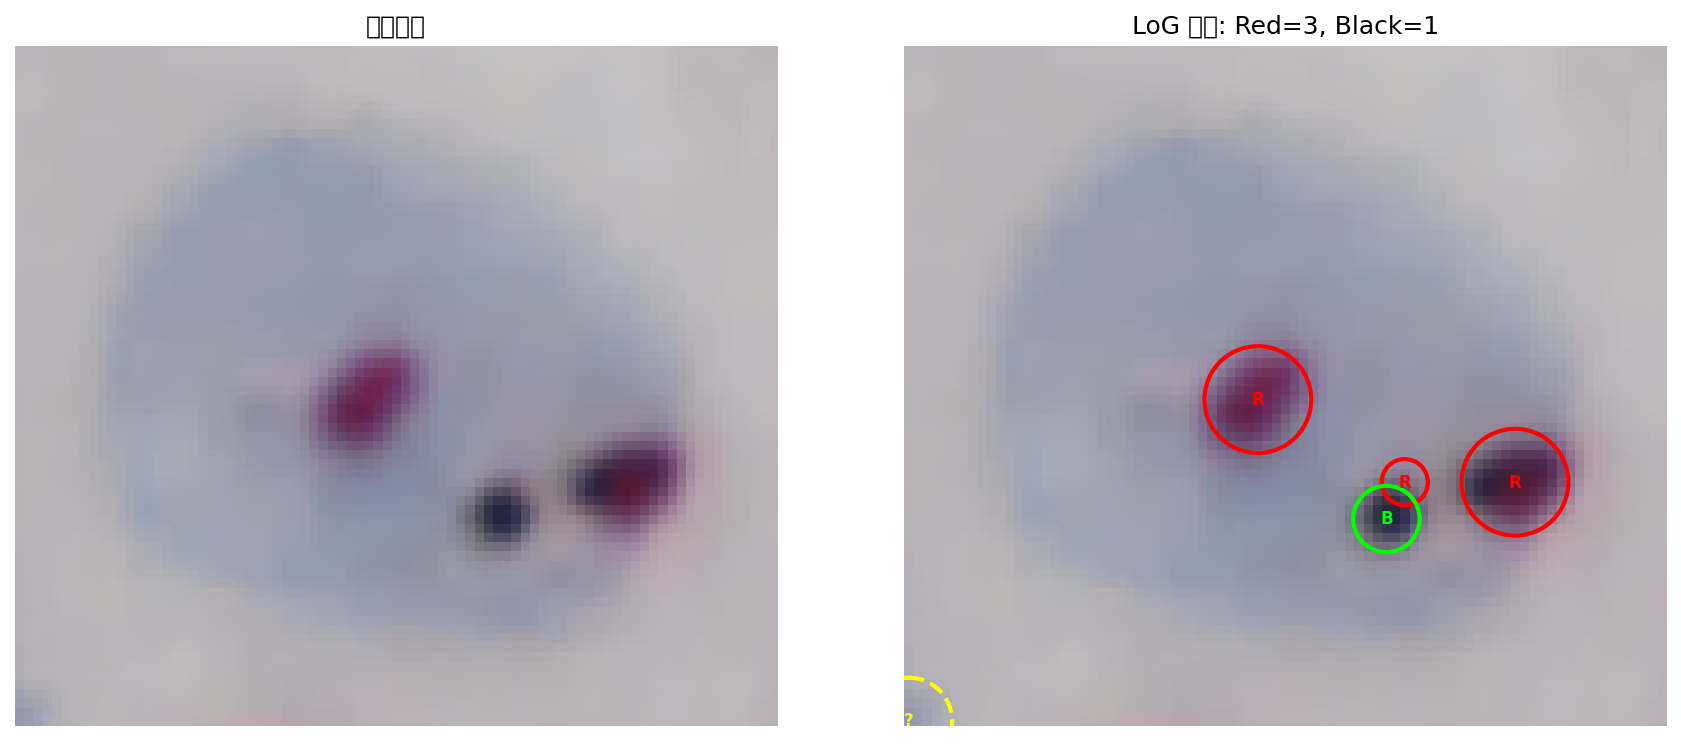

  Red dots:   3
  Black dots: 1
  Ratio (black/red): 0.33

  CSV 舊結果: red=0, black=0 (全部漏掉)
  目視:       red≈2, black≈1


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img)
axes[0].set_title("原始影像")

axes[1].imshow(img)
axes[1].set_title(f"LoG 結果: Red={len(classified_red)}, Black={len(classified_black)}")

# 畫紅色 dot (紅圈)
for info in classified_red:
    y, x, sigma = info["blob"]
    radius = sigma * np.sqrt(2)
    circle = plt.Circle((x, y), radius, color="red", linewidth=2, fill=False)
    axes[1].add_patch(circle)
    axes[1].annotate("R", (x, y), color="red", fontsize=8, fontweight="bold",
                     ha="center", va="center")

# 畫黑色 dot (綠圈)
for info in classified_black:
    y, x, sigma = info["blob"]
    radius = sigma * np.sqrt(2)
    circle = plt.Circle((x, y), radius, color="lime", linewidth=2, fill=False)
    axes[1].add_patch(circle)
    axes[1].annotate("B", (x, y), color="lime", fontsize=8, fontweight="bold",
                     ha="center", va="center")

# 畫未分類 (黃圈)
for info in classified_other:
    y, x, sigma = info["blob"]
    radius = sigma * np.sqrt(2)
    circle = plt.Circle((x, y), radius, color="yellow", linewidth=2, fill=False, linestyle="--")
    axes[1].add_patch(circle)
    axes[1].annotate("?", (x, y), color="yellow", fontsize=8, fontweight="bold",
                     ha="center", va="center")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

# 最終報告
print("=" * 50)
print(f"  Red dots:   {len(classified_red)}")
print(f"  Black dots: {len(classified_black)}")
if len(classified_red) > 0:
    print(f"  Ratio (black/red): {len(classified_black)/len(classified_red):.2f}")
else:
    ratio_str = "inf" if len(classified_black) > 0 else "nan"
    print(f"  Ratio (black/red): {ratio_str}")
print("=" * 50)
print(f"\n  CSV 舊結果: red=0, black=0 (全部漏掉)")
print(f"  目視:       red≈2, black≈1")

## Step 6: 參數敏感度 — threshold 對結果的影響

掃描不同 threshold 值，看 blob 數量怎麼變化

/tmp/ipykernel_3918300/249434143.py:23: UserWarning: Glyph 25935 (\N{CJK UNIFIED IDEOGRAPH-654F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3918300/249434143.py:23: UserWarning: Glyph 24863 (\N{CJK UNIFIED IDEOGRAPH-611F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3918300/249434143.py:23: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3918300/249434143.py:23: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3918300/249434143.py:23: UserWarning: Glyph 26512 (\N{CJK UNIFIED IDEOGRAPH-6790}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/sec312/project/tsgh/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25935 (\N{CJK UNIFIED IDEOGRAPH-654F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/se

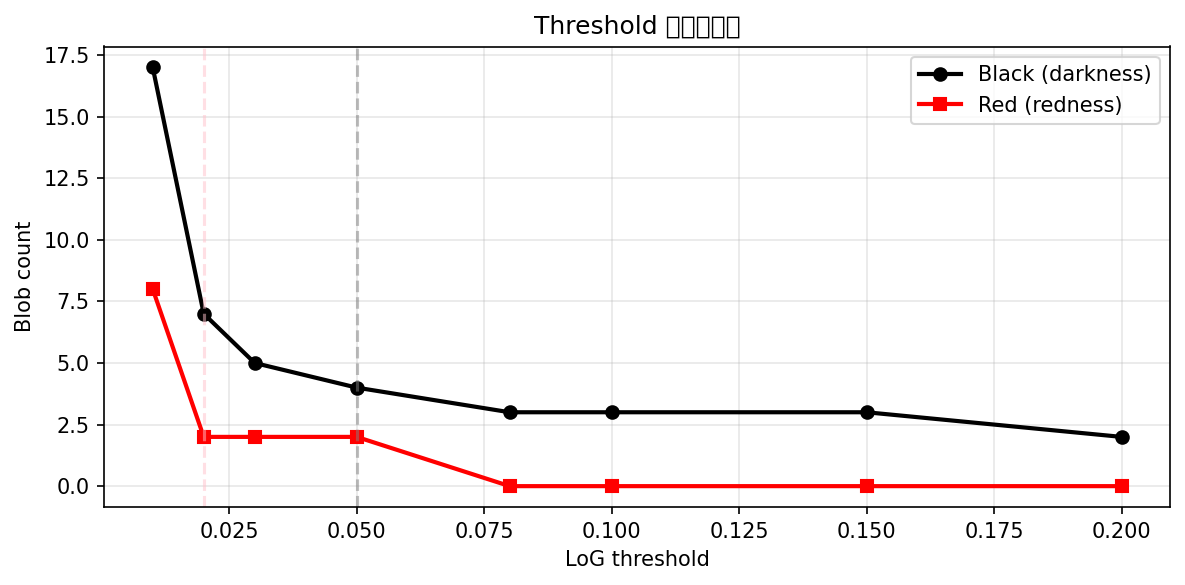

  threshold=0.01: black=17, red=8
  threshold=0.02: black=7, red=2
  threshold=0.03: black=5, red=2
  threshold=0.05: black=4, red=2
  threshold=0.08: black=3, red=0
  threshold=0.10: black=3, red=0
  threshold=0.15: black=3, red=0
  threshold=0.20: black=2, red=0


In [17]:
thresholds = [0.01, 0.02, 0.03, 0.05, 0.08, 0.10, 0.15, 0.20]

black_counts = []
red_counts = []

for t in thresholds:
    b = blob_log(darkness, min_sigma=1, max_sigma=8, num_sigma=10, threshold=t)
    r_blobs = blob_log(redness, min_sigma=1, max_sigma=8, num_sigma=10, threshold=t)
    black_counts.append(len(b))
    red_counts.append(len(r_blobs))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, black_counts, "ko-", label="Black (darkness)", linewidth=2)
ax.plot(thresholds, red_counts, "rs-", label="Red (redness)", linewidth=2)
ax.set_xlabel("LoG threshold")
ax.set_ylabel("Blob count")
ax.set_title("Threshold 敏感度分析")
ax.legend()
ax.grid(True, alpha=0.3)
# 標出目前使用的 threshold
ax.axvline(0.05, color="gray", linestyle="--", alpha=0.5, label="black thresh=0.05")
ax.axvline(0.02, color="pink", linestyle="--", alpha=0.5, label="red thresh=0.02")
plt.tight_layout()
plt.show()

for t, bc, rc in zip(thresholds, black_counts, red_counts):
    print(f"  threshold={t:.2f}: black={bc}, red={rc}")

## Step 7: 多張 cell 批次測試

用同一組參數跑其他 cell，看 LoG 的泛化效果

/tmp/ipykernel_3918300/16092134.py:69: UserWarning: Glyph 25209 (\N{CJK UNIFIED IDEOGRAPH-6279}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3918300/16092134.py:69: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3918300/16092134.py:69: UserWarning: Glyph 32080 (\N{CJK UNIFIED IDEOGRAPH-7D50}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3918300/16092134.py:69: UserWarning: Glyph 26524 (\N{CJK UNIFIED IDEOGRAPH-679C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/sec312/project/tsgh/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25209 (\N{CJK UNIFIED IDEOGRAPH-6279}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sec312/project/tsgh/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from f

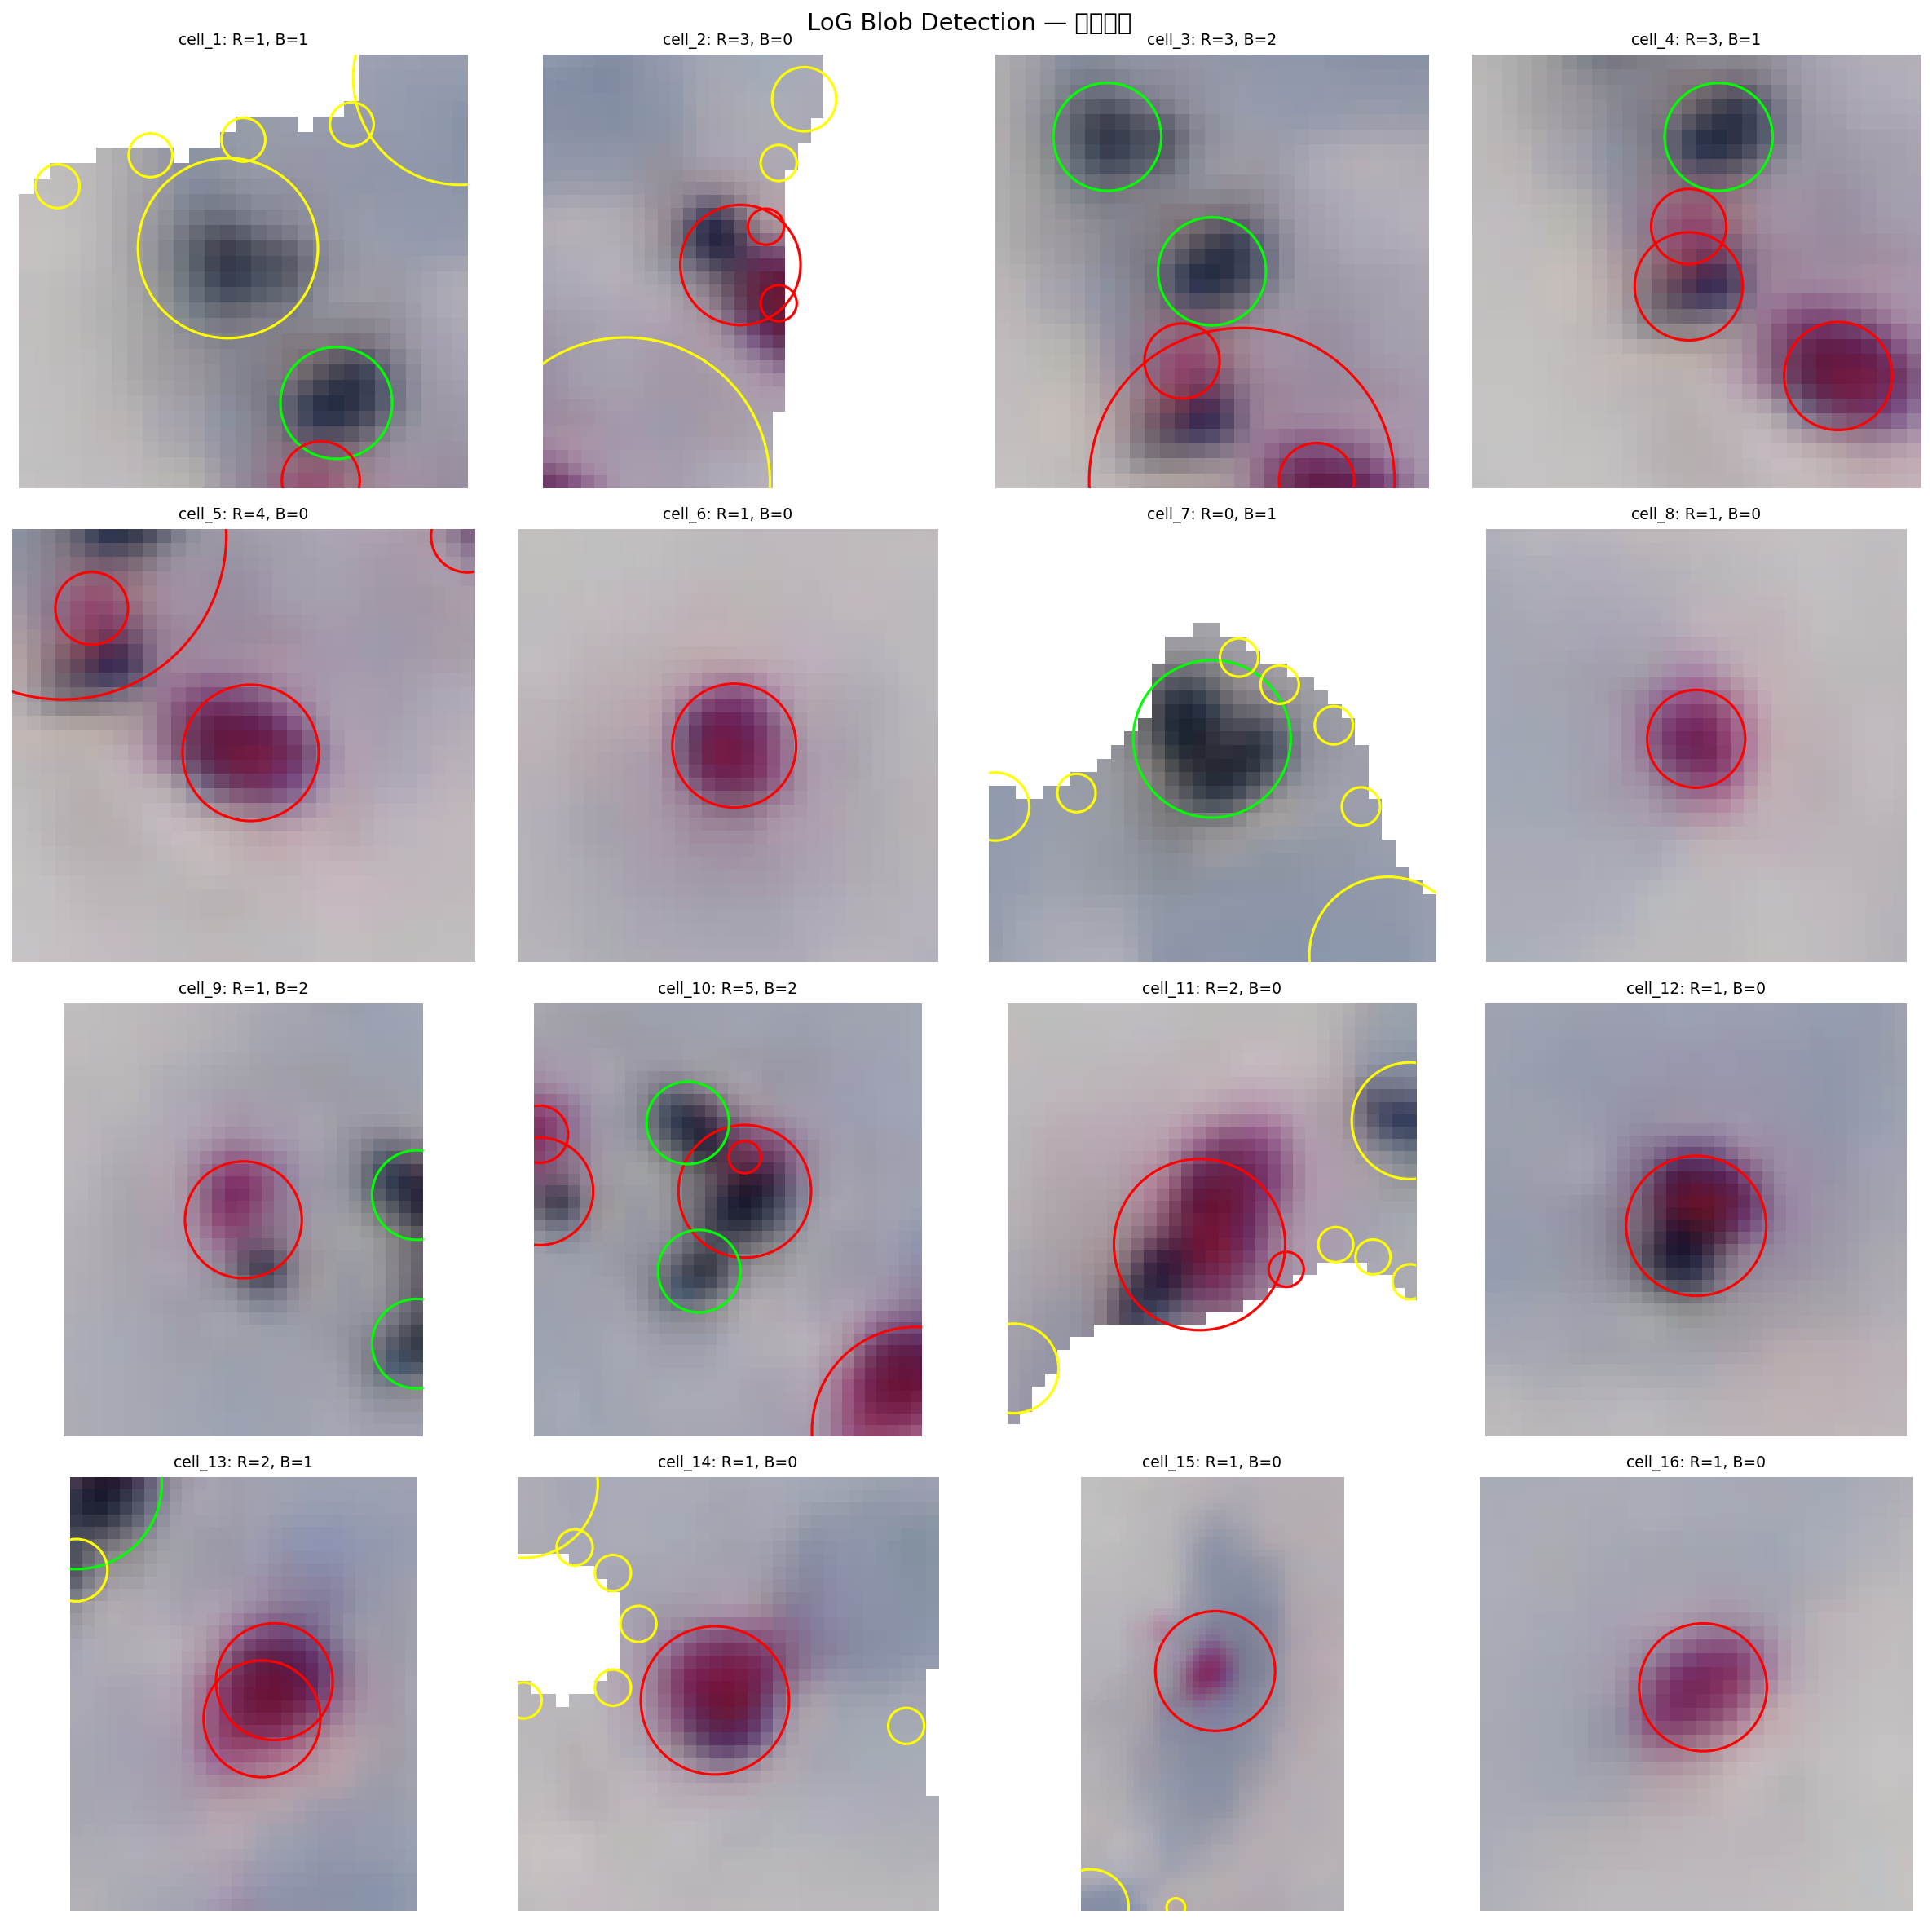

In [18]:
import os
from pathlib import Path

cells_dir = Path("output/tile_x55296_y94208/cells")
cell_files = sorted(cells_dir.glob("cell_*.png"), key=lambda p: int(p.stem.split("_")[1]))

# 取一些有代表性的 cell (包含 cell_24 以外的)
sample_cells = cell_files[:16]  # 前 16 張

def detect_blobs_for_cell(cell_path):
    """對單張 cell 跑完整 LoG pipeline"""
    c_img = np.array(Image.open(cell_path))
    c_f = c_img.astype(np.float64) / 255.0
    c_r, c_g, c_b = c_f[:,:,0], c_f[:,:,1], c_f[:,:,2]

    c_darkness = 1.0 - c_f.mean(axis=2)
    c_redness = np.clip(c_r - np.maximum(c_g, c_b), 0, 1)
    c_lab = color.rgb2lab(c_f)

    # LoG
    b_black = blob_log(c_darkness, min_sigma=1, max_sigma=8, num_sigma=10, threshold=0.05)
    b_red = blob_log(c_redness, min_sigma=1, max_sigma=8, num_sigma=10, threshold=0.02)

    # 合併去重
    all_b = list(b_black) + list(b_red)
    all_s = ["dark"] * len(b_black) + ["red"] * len(b_red)
    unique_b, unique_s = deduplicate_blobs(all_b, all_s)

    # 分類
    reds, blacks, others = 0, 0, 0
    blob_info = []
    for blob, src in zip(unique_b, unique_s):
        y, x, sigma = blob
        yi, xi = int(round(y)), int(round(x))
        rad = max(int(sigma * np.sqrt(2)), 2)
        y_lo, y_hi = max(0, yi-rad), min(c_img.shape[0], yi+rad+1)
        x_lo, x_hi = max(0, xi-rad), min(c_img.shape[1], xi+rad+1)

        patch_bright = c_f[y_lo:y_hi, x_lo:x_hi].mean()
        patch_a = c_lab[y_lo:y_hi, x_lo:x_hi, 1].mean()
        patch_redness = c_redness[y_lo:y_hi, x_lo:x_hi].mean()

        is_r = (patch_a > 8 or patch_redness > 0.03) and patch_bright > 0.25
        is_b = patch_bright < 0.45 and patch_a < 8 and patch_redness < 0.03

        label = "R" if is_r else ("B" if is_b else "?")
        if is_r: reds += 1
        elif is_b: blacks += 1
        else: others += 1
        blob_info.append((blob, label))

    return c_img, blob_info, reds, blacks

# 跑批次
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
for idx, (ax, cell_path) in enumerate(zip(axes.flat, sample_cells)):
    c_img, blob_info, reds, blacks = detect_blobs_for_cell(cell_path)
    ax.imshow(c_img)
    for blob, label in blob_info:
        y, x, sigma = blob
        radius = sigma * np.sqrt(2)
        c = "red" if label == "R" else ("lime" if label == "B" else "yellow")
        circle = plt.Circle((x, y), radius, color=c, linewidth=1.5, fill=False)
        ax.add_patch(circle)
    ax.set_title(f"{cell_path.stem}: R={reds}, B={blacks}", fontsize=9)
    ax.axis("off")

plt.suptitle("LoG Blob Detection — 批次結果", fontsize=14)
plt.tight_layout()
plt.show()